# 01 · Integración y calidad de datos

**Objetivo:** unir football-data.co.uk y Understat en una tabla fiable de partidos de LaLiga, comprobando que las dos fuentes cuentan la misma historia.

**Decisiones tomadas hasta aquí**

| Decisión | Elección | Motivo |
|---|---|---|
| Temporadas de análisis | 2014/15 – 2025/26 | Understat (xG) empieza en 2014/15 |
| Calentamiento del Elo | 2012/13 y 2013/14 (solo football-data) | Que en 2014/15 los equipos no empiecen todos con la misma fuerza |
| Datos brutos | Tal cual llegan, nunca se editan | Cualquier corrección queda documentada en código |
| Ascendidos | Heredan el Elo medio de los descendidos + K más alto sus primeras N jornadas, que se excluyen del entrenamiento y la evaluación | Evitar el sesgo de supervivencia sin usar información del futuro |
| Herramienta | SQL (DuckDB) para limpiar, integrar y validar; pandas donde SQL se fuerce | SQL es la habilidad central de un analista |
| Formato de salida | CSV (fechas ISO, punto decimal, UTF-8) | Legible por Power BI y Excel |
| Cuotas de apuestas | No se usan | El proyecto mide rendimiento futbolístico; el listón serán modelos de referencia ingenuos |
| Estadísticas de partido | Se conservan todas | Solo como información de partidos **anteriores**, nunca del partido que se predice |
| Nombres de equipos | Tabla manual `data/equipos.csv`, nombres en español | Explícita y auditable; el emparejamiento automático puede fallar en silencio |
| Clave de cruce | temporada + local + visitante | La fecha no coincide entre fuentes en 70 partidos (ver sección 6) |
| Fecha oficial | La de football-data | Una sola fuente para las 14 temporadas; Understat tiene horas imposibles |
| Estructura | `partidos` (una fila por partido) + `partidos_equipo` (una fila por equipo y partido, generada desde la anterior) | Cada fase usa el formato que le conviene |
| Nombres de columnas | Español descriptivo | Coherente con el resto del proyecto |
| PPDA | Se guardan las piezas (pases y acciones), no el ratio | La media de ratios no es el ratio de totales |
| Calidad, nivel 1 | Reglas de imposibles lógicos como validaciones que detienen el notebook | Protegen frente a cambios futuros en las fuentes |
| Calidad, nivel 2 | Detección con rango intercuartílico (diagramas de caja); los extremos se conservan y se documentan (sección 11) | Un outlier estadístico no es un error; borrar extremos reales también sesga |


## 0. Preparación

In [1]:
from pathlib import Path

import duckdb
import pandas as pd

ROOT = Path.cwd().parent                       # el notebook se ejecuta desde notebooks/
RAW = ROOT / "data" / "raw"
FD_FILES = (RAW / "football_data" / "*.csv").as_posix()
US_FILES = (RAW / "understat" / "*.json").as_posix()

con = duckdb.connect()                         # base de datos en memoria: los datos se leen de los ficheros
pd.set_option("display.max_columns", 30)

## 1. football-data: una fila por partido

Leemos los 14 CSV con **una sola consulta**. Las opciones de `read_csv` resuelven problemas concretos:

| Opción | Problema que resuelve |
|---|---|
| `*.csv` | Leer todas las temporadas a la vez |
| `union_by_name=true` | Las columnas cambian con los años (67 en 2014/15, 131 en 2025/26). Alinea por **nombre** y deja `NULL` donde una temporada no tiene esa columna |
| `filename=true` | Añade el nombre del fichero, de donde sacamos la temporada |
| `all_varchar=true` | Lee **todo como texto**. En la capa bruta no dejamos que DuckDB adivine tipos: la fecha viene como `23/08/14` unos años y `15/08/2025` otros, y una detección automática podría interpretarla mal. Los tipos se asignan a propósito en la limpieza |

Creamos una **vista** (`VIEW`): una consulta guardada con nombre. No copia datos; cada vez que la usamos, relee los CSV.

In [2]:
con.sql(f"""
CREATE OR REPLACE VIEW fd_raw AS
SELECT
    regexp_extract(filename, '(\\d{{4}}-\\d{{2}})\\.csv$', 1) AS temporada,
    * EXCLUDE (filename)
FROM read_csv('{FD_FILES}', union_by_name=true, filename=true, all_varchar=true)
""")

con.sql("""
SELECT temporada,
       count(*)                                        AS filas,
       count(DISTINCT HomeTeam)                        AS equipos,
       count(*) FILTER (WHERE FTR IN ('H', 'D', 'A'))  AS con_resultado
FROM fd_raw
GROUP BY temporada
ORDER BY temporada
""").df()

,temporada,filas,equipos,con_resultado
0,2012-13,380,20,380
1,2013-14,380,20,380
2,2014-15,380,20,380
3,2015-16,380,20,380
4,2016-17,380,20,380
5,2017-18,380,20,380
6,2018-19,380,20,380
7,2019-20,380,20,380
8,2020-21,380,20,380
9,2021-22,380,20,380


In [3]:
n_cols = len(con.sql("DESCRIBE fd_raw").df())
print(f"Columnas tras unir todas las temporadas: {n_cols}")

Columnas tras unir todas las temporadas: 189


## 2. ¿Qué columnas existen en cada temporada?

Antes de elegir variables hay que saber **en qué temporadas existen**. Una columna que solo aparece desde 2019/20 no se puede usar en un modelo entrenado desde 2014/15 sin perder temporadas o inventar valores.

Medimos el % de partidos con dato para cada grupo de columnas candidatas:

In [4]:
candidatas = {
    "Resultado (FTR)": "FTR",
    "Tiros (HS)": "HS",
    "Tiros a puerta (HST)": "HST",
    "Córners (HC)": "HC",
    "Tarjetas (HY)": "HY",
    "Hora (Time)": "Time",
    "Bet365 apertura": "B365H",
    "Bet365 cierre": "B365CH",
    "Pinnacle apertura": "PSH",
    "Pinnacle cierre": "PSCH",
    "Media mercado (Betbrain)": "BbAvH",
    "Media mercado apertura": "AvgH",
    "Media mercado cierre": "AvgCH",
}
cols_sql = ",\n".join(
    f'round(100 * count("{col}") / count(*)) AS "{nombre}"' for nombre, col in candidatas.items()
)
cobertura = con.sql(f"SELECT temporada, {cols_sql} FROM fd_raw GROUP BY temporada ORDER BY temporada").df()
cobertura.set_index("temporada").T.astype(int)

temporada,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
Resultado (FTR),100,100,100,100,100,100,100,100,100,100,100,100,100,100
Tiros (HS),100,100,100,100,100,100,100,100,100,100,100,100,100,100
Tiros a puerta (HST),100,100,100,100,100,100,100,100,100,100,100,100,100,100
Córners (HC),100,100,100,100,100,100,100,100,100,100,100,100,100,100
Tarjetas (HY),100,100,100,100,100,100,100,100,100,100,100,100,100,100
Hora (Time),0,0,0,0,0,0,0,100,100,100,100,100,100,100
Bet365 apertura,100,100,100,100,100,100,100,100,100,100,100,100,100,100
Bet365 cierre,0,0,0,0,0,0,0,100,100,100,100,100,100,100
Pinnacle apertura,100,100,99,100,100,100,100,99,100,100,100,100,100,50
Pinnacle cierre,100,100,100,100,100,100,100,100,100,100,100,100,100,49


**Qué vemos** (100 = todos los partidos tienen el dato):

- **Estadísticas de partido** (tiros, córners, tarjetas): completas en las 14 temporadas.
- **Hora del partido:** solo desde 2019/20.
- **Pinnacle** (apertura y cierre): completo desde 2012/13… salvo la **2025/26, donde se corta a mitad de temporada** (lo comprobamos abajo).
- **Media del mercado:** cambia de nombre y de origen. Hasta 2018/19 es `BbAv` (del agregador Betbrain, que cerró) y desde 2019/20 es `Avg`. Es el mismo concepto calculado por fuentes distintas.
- **Bet365 cierre y media de cierre:** solo desde 2019/20.

In [5]:
con.sql("""
SELECT PSCH IS NOT NULL                    AS tiene_pinnacle,
       min(strptime(Date, '%d/%m/%Y'))::DATE AS desde,
       max(strptime(Date, '%d/%m/%Y'))::DATE AS hasta,
       count(*)                            AS partidos
FROM fd_raw
WHERE temporada = '2025-26'
GROUP BY 1
""").df()

,tiene_pinnacle,desde,hasta,partidos
0,False,2025-12-15,2026-05-24,192
1,True,2025-08-15,2026-01-12,188


Pinnacle deja de publicar cuotas de LaLiga en football-data **a partir de mediados de enero de 2026**. Hay un pequeño solape de fechas porque se jugaron partidos aplazados fuera de orden. Esto importa: Pinnacle es la casa de referencia en la literatura de predicción deportiva (la de márgenes más bajos) y la 2025/26 era candidata a temporada de test.

## 3. Understat: calendario de partidos

El JSON de Understat es **anidado**: cada partido tiene dentro sub-objetos (`h` = local, `a` = visitante, `goals`, `xG`…).

- `unnest(dates)` convierte la lista de 380 partidos de cada fichero en 380 filas.
- La notación con punto (`m.h.title`) entra en los sub-objetos.

Aquí nos quedamos solo con el bloque `dates` (una fila por partido). El bloque `teams` (estadísticas por equipo y partido: PPDA, pases profundos…) lo aplanaremos más adelante.

In [6]:
con.sql(f"""
CREATE OR REPLACE VIEW us_partidos_raw AS
WITH src AS (
    SELECT regexp_extract(filename, '(\\d{{4}}-\\d{{2}})\\.json$', 1) AS temporada,
           unnest(dates) AS m
    FROM read_json('{US_FILES}', filename=true, maximum_object_size=10000000)
)
SELECT temporada,
       m.id         AS id_understat,
       m.datetime   AS fecha_hora,
       m.h.title    AS local,
       m.a.title    AS visitante,
       m.goals.h    AS goles_local,
       m.goals.a    AS goles_visitante,
       m.xG.h       AS xg_local,
       m.xG.a       AS xg_visitante,
       m.isResult   AS jugado
FROM src
""")

con.sql("""
SELECT temporada, count(*) AS partidos, count(DISTINCT local) AS equipos, count(*) FILTER (WHERE jugado) AS jugados
FROM us_partidos_raw
GROUP BY temporada
ORDER BY temporada
""").df()

,temporada,partidos,equipos,jugados
0,2014-15,380,20,380
1,2015-16,380,20,380
2,2016-17,380,20,380
3,2017-18,380,20,380
4,2018-19,380,20,380
5,2019-20,380,20,380
6,2020-21,380,20,380
7,2021-22,380,20,380
8,2022-23,380,20,380
9,2023-24,380,20,380


In [7]:
con.sql("SELECT * FROM us_partidos_raw LIMIT 5").df()

,temporada,id_understat,fecha_hora,local,visitante,goles_local,goles_visitante,xg_local,xg_visitante,jugado
0,2014-15,5826,2014-08-23 18:00:00,Malaga,Athletic Club,1,0,1.32107,1.14151,True
1,2014-15,5827,2014-08-23 20:00:00,Sevilla,Valencia,1,1,1.17197,1.74903,True
2,2014-15,5828,2014-08-23 20:00:00,Granada,Deportivo La Coruna,2,1,0.548351,0.379371,True
3,2014-15,5829,2014-08-23 22:00:00,Almeria,Espanyol,1,1,0.978788,0.399306,True
4,2014-15,5830,2014-08-24 18:00:00,Eibar,Real Sociedad,1,0,0.465398,0.975523,True


Las dos fuentes tienen **380 partidos por temporada y 20 equipos**. Antes de unirlas hay que decidir qué columnas de football-data conservamos, cómo se llaman los equipos en cada fuente y con qué clave identificamos un partido.

## 4. Fechas y nombres normalizados

### La trampa de las fechas

football-data escribe la fecha como `23/08/14` hasta 2017/18 y como `15/08/2025` después. Si intentamos leer todo con el formato de año de 4 cifras (`%Y`), **no da error**: interpreta `14` como el año 14 después de Cristo.

In [8]:
con.sql("""
SELECT '23/08/14'                                   AS texto,
       year(try_strptime('23/08/14', '%d/%m/%Y'))   AS año_leido_con_4_cifras,
       year(try_strptime('23/08/14', '%d/%m/%y'))   AS año_leido_con_2_cifras
""").df()

,texto,año_leido_con_4_cifras,año_leido_con_2_cifras
0,23/08/14,14,2014


Es un **fallo silencioso**: nada avisa, pero 1.520 partidos quedarían fechados hace dos mil años. La solución es elegir el formato según la **longitud** del texto (8 caracteres → año de 2 cifras). La salida es siempre un `DATE` con año de 4 cifras.

### Nombres en español

Sustituimos los nombres de cada fuente por los de `data/equipos.csv` con un `JOIN`. Ojo: un `JOIN` normal (**INNER**) **descarta en silencio** las filas que no encuentran pareja. Si un nombre faltara en la tabla de equivalencias, perderíamos sus partidos sin enterarnos. Por eso, después contamos filas antes y después.

In [9]:
EQUIPOS = (ROOT / "data" / "equipos.csv").as_posix()
con.sql(f"CREATE OR REPLACE VIEW equipos AS SELECT * FROM read_csv('{EQUIPOS}')")

con.sql("""
CREATE OR REPLACE VIEW fd_partidos AS
SELECT f.temporada,
       CASE WHEN length(f.Date) = 8 THEN strptime(f.Date, '%d/%m/%y')
            ELSE strptime(f.Date, '%d/%m/%Y') END::DATE AS fecha,
       el.nombre         AS local,
       ev.nombre         AS visitante,
       f.FTHG::INTEGER   AS goles_local,
       f.FTAG::INTEGER   AS goles_visitante,
       CASE f.FTR WHEN 'H' THEN '1' WHEN 'D' THEN 'X' WHEN 'A' THEN '2' END AS resultado,
       f.HS::INTEGER     AS tiros_local,
       f."AS"::INTEGER   AS tiros_visitante,
       f.HST::INTEGER    AS tiros_puerta_local,
       f.AST::INTEGER    AS tiros_puerta_visitante,
       f.HC::INTEGER     AS corners_local,
       f.AC::INTEGER     AS corners_visitante,
       f.HF::INTEGER     AS faltas_local,
       f.AF::INTEGER     AS faltas_visitante,
       f.HY::INTEGER     AS amarillas_local,
       f.AY::INTEGER     AS amarillas_visitante,
       f.HR::INTEGER     AS rojas_local,
       f.AR::INTEGER     AS rojas_visitante
FROM fd_raw f
JOIN equipos el ON f.HomeTeam = el.nombre_football_data
JOIN equipos ev ON f.AwayTeam = ev.nombre_football_data
""")

con.sql("""
CREATE OR REPLACE VIEW us_partidos AS
SELECT u.temporada,
       u.fecha_hora::TIMESTAMP     AS fecha_hora,
       el.nombre                   AS local,
       ev.nombre                   AS visitante,
       u.goles_local::INTEGER      AS goles_local,
       u.goles_visitante::INTEGER  AS goles_visitante,
       u.xg_local::DOUBLE          AS xg_local,
       u.xg_visitante::DOUBLE      AS xg_visitante,
       u.id_understat
FROM us_partidos_raw u
JOIN equipos el ON u.local = el.nombre_understat
JOIN equipos ev ON u.visitante = ev.nombre_understat
""")

filas = con.sql("""
SELECT (SELECT count(*) FROM fd_raw)          AS fd_antes,
       (SELECT count(*) FROM fd_partidos)     AS fd_despues,
       (SELECT count(*) FROM us_partidos_raw) AS us_antes,
       (SELECT count(*) FROM us_partidos)     AS us_despues
""").df()
assert filas.fd_antes[0] == filas.fd_despues[0], "football-data: hay nombres sin equivalencia"
assert filas.us_antes[0] == filas.us_despues[0], "Understat: hay nombres sin equivalencia"
filas

,fd_antes,fd_despues,us_antes,us_despues
0,5320,5320,4560,4560


Los `assert` son **validaciones que detienen el notebook** si no se cumplen. Si algún día una fuente cambia un nombre, el notebook fallará aquí con un mensaje claro, en vez de seguir con partidos perdidos.

## 5. Cruce de las dos fuentes

**Clave elegida:** `temporada + local + visitante`. Se apoya en una regla de la competición: en una liga a doble vuelta, cada pareja juega **exactamente una vez** en cada campo por temporada.

Esa regla no la damos por supuesta: la **comprobamos** en ambas fuentes antes de cruzar. Si hubiera un duplicado, el cruce multiplicaría filas.

In [10]:
duplicados = con.sql("""
SELECT 'football-data' AS fuente, count(*) - count(DISTINCT (temporada, local, visitante)) AS claves_repetidas FROM fd_partidos
UNION ALL
SELECT 'Understat', count(*) - count(DISTINCT (temporada, local, visitante)) FROM us_partidos
""").df()
assert (duplicados.claves_repetidas == 0).all(), "La clave no es única: revisar antes de cruzar"
duplicados

,fuente,claves_repetidas
0,football-data,0
1,Understat,0


Cruzamos con un **LEFT JOIN desde football-data**: se conservan todos sus partidos aunque no tengan pareja en Understat. Así las temporadas de calentamiento (2012/13 y 2013/14, anteriores a Understat) siguen en la tabla, con el xG vacío.

In [11]:
con.sql("""
CREATE OR REPLACE VIEW partidos_cruce AS
SELECT fd.*,
       us.fecha_hora      AS us_fecha_hora,
       us.goles_local     AS us_goles_local,
       us.goles_visitante AS us_goles_visitante,
       us.xg_local,
       us.xg_visitante,
       us.id_understat
FROM fd_partidos fd
LEFT JOIN us_partidos us USING (temporada, local, visitante)
""")

con.sql("""
SELECT temporada,
       count(*)               AS partidos,
       count(id_understat)    AS con_understat
FROM partidos_cruce
GROUP BY temporada
ORDER BY temporada
""").df()

,temporada,partidos,con_understat
0,2012-13,380,0
1,2013-14,380,0
2,2014-15,380,380
3,2015-16,380,380
4,2016-17,380,380
5,2017-18,380,380
6,2018-19,380,380
7,2019-20,380,380
8,2020-21,380,380
9,2021-22,380,380


Falta la comprobación inversa: ¿hay partidos de Understat que **no** encontraron pareja en football-data? Para eso se usa un **anti-join**: las filas de una tabla que no tienen pareja en la otra.

In [12]:
huerfanos = con.sql("""
SELECT us.* FROM us_partidos us
ANTI JOIN fd_partidos fd USING (temporada, local, visitante)
""").df()
assert huerfanos.empty, f"{len(huerfanos)} partidos de Understat sin pareja"
print("Partidos de Understat sin pareja en football-data:", len(huerfanos))

Partidos de Understat sin pareja en football-data: 0


## 6. ¿Las dos fuentes cuentan lo mismo?

Tener dos fuentes independientes es una ventaja: si coinciden, ganamos confianza; si no, detectamos errores. Comparamos **goles** y **fechas** partido a partido.

### Goles

In [13]:
con.sql("""
SELECT count(*)                                                        AS partidos_comparados,
       count(*) FILTER (WHERE goles_local <> us_goles_local
                           OR goles_visitante <> us_goles_visitante)   AS goles_distintos
FROM partidos_cruce
WHERE id_understat IS NOT NULL
""").df()

,partidos_comparados,goles_distintos
0,4560,0


### Fechas

Comparamos la fecha de football-data con la de Understat (su fecha y hora, reducida a día). Esto es un **informe de calidad**: no cambia ningún dato.

In [14]:
con.sql("""
SELECT us_fecha_hora::DATE - fecha AS dias_de_diferencia,
       count(*)                    AS partidos
FROM partidos_cruce
WHERE id_understat IS NOT NULL
GROUP BY 1
ORDER BY 1
""").df()

,dias_de_diferencia,partidos
0,-1,1
1,0,4490
2,1,69


70 partidos no coinciden. ¿Por qué? Miramos a qué **hora** están en Understat:

In [15]:
con.sql("""
SELECT CASE WHEN hour(us_fecha_hora) < 2 THEN 'Understat: entre 00:00 y 01:59'
            ELSE 'Understat: otra hora' END AS hora_en_understat,
       count(*) AS partidos
FROM partidos_cruce
WHERE us_fecha_hora::DATE <> fecha
GROUP BY 1
""").df()

,hora_en_understat,partidos
0,Understat: entre 00:00 y 01:59,65
1,Understat: otra hora,5


In [16]:
con.sql("""
SELECT temporada, local, visitante, fecha AS fecha_football_data, us_fecha_hora AS fecha_hora_understat
FROM partidos_cruce
WHERE us_fecha_hora::DATE <> fecha AND hour(us_fecha_hora) >= 2
""").df()

,temporada,local,visitante,fecha_football_data,fecha_hora_understat
0,2021-22,Espanyol,Valencia,2022-05-14,2022-05-15 17:30:00
1,2017-18,Eibar,Leganés,2017-09-15,2017-09-16 06:00:00
2,2017-18,Barcelona,Sevilla,2017-11-04,2017-11-05 03:45:00
3,2023-24,Granada,Athletic Club,2023-12-11,2023-12-12 15:15:00
4,2025-26,Valencia,Real Oviedo,2025-09-30,2025-09-29 19:00:00


**Conclusiones:**

- **Goles:** coinciden en los 4.560 partidos. Las dos fuentes son coherentes en lo esencial.
- **65 fechas distintas por zona horaria:** Understat registra los partidos nocturnos pasada la medianoche, en otra zona horaria. No es un error de ninguna fuente, pero **si hubiéramos cruzado por fecha habríamos perdido justo los partidos nocturnos**: una pérdida no aleatoria.
- **5 discrepancias de otro tipo:**
  - *Eibar–Leganés (2017/18) a las 06:00* y *Barcelona–Sevilla (2017/18) a las 03:45*: horas imposibles para un partido de LaLiga. Lo más probable es un error de hora en Understat.
  - *Granada–Athletic (2023/24):* el partido se suspendió el 11 de diciembre de 2023 tras el fallecimiento de un aficionado en la grada y se completó al día siguiente. Cada fuente registra un día distinto.
  - *Espanyol–Valencia (2021/22)* y *Valencia–Real Oviedo (2025/26):* diferencia de un día sin explicación evidente; una de las dos fuentes se equivoca.

**Decisión:** la fecha oficial es la de football-data: una sola fuente para las 14 temporadas, y Understat tiene horas imposibles. El impacto es mínimo: un día de diferencia no altera el orden de los partidos de ningún equipo.

## 7. Understat: estadísticas por equipo y partido

El bloque `teams` tiene lo que no está en `dates`: **xG sin penaltis, PPDA, pases profundos y puntos esperados**. Su estructura es de dos niveles:

```
teams: { "138": { title: "Sevilla", history: [ {partido 1}, {partido 2}, … ] },
         "137": { … } }
```

- `teams` es un **diccionario** con clave = identificador del equipo. Lo leemos como tipo `MAP` y sacamos sus valores con `map_values`.
- Cada equipo tiene una **lista** `history` con sus 38 partidos: un segundo `unnest` la convierte en filas.
- `p->>'xG'` extrae un campo del JSON como texto; después lo convertimos a su tipo.

**Qué significa cada variable** (desde el punto de vista del equipo de la fila):

| Variable | Significado |
|---|---|
| `npxg` | xG sin penaltis: la calidad de las ocasiones creadas en juego |
| `ppda_pases` | Pases que el **rival** completó en su propio campo… |
| `ppda_acciones` | …y acciones defensivas del equipo en esa zona. PPDA = pases ÷ acciones: **cuanto más bajo, más presión** |
| `pases_profundos` | Pases completados a menos de ~20 m de la portería rival (sin contar centros) |
| `puntos_esperados` | Puntos que "merecía" según el xG del partido. ⚠️ **Se calcula con datos del propio partido**: sirve para analizar suerte (fase 5), nunca para predecir ese partido |

In [17]:
con.sql(f"""
CREATE OR REPLACE VIEW us_equipo_partido AS
WITH equipos_json AS (
    SELECT regexp_extract(filename, '(\\d{{4}}-\\d{{2}})\\.json$', 1) AS temporada,
           unnest(map_values(teams)) AS eq
    FROM read_json('{US_FILES}', filename=true, maximum_object_size=10000000,
                   columns={{teams: 'MAP(VARCHAR, STRUCT(id VARCHAR, title VARCHAR, history JSON[]))'}})
),
historial AS (
    SELECT temporada, eq.title AS equipo_understat, unnest(eq.history) AS p
    FROM equipos_json
)
SELECT h.temporada,
       e.nombre                                    AS equipo,
       (p->>'date')::TIMESTAMP                     AS fecha_hora,
       CASE p->>'h_a' WHEN 'h' THEN 'local' ELSE 'visitante' END AS condicion,
       (p->>'xG')::DOUBLE                          AS xg,
       (p->>'npxG')::DOUBLE                        AS npxg,
       (p->>'npxGA')::DOUBLE                       AS npxg_contra,
       (p->'ppda'->>'att')::INTEGER                AS ppda_pases,
       (p->'ppda'->>'def')::INTEGER                AS ppda_acciones,
       (p->'ppda_allowed'->>'att')::INTEGER        AS ppda_permitido_pases,
       (p->'ppda_allowed'->>'def')::INTEGER        AS ppda_permitido_acciones,
       (p->>'deep')::INTEGER                       AS pases_profundos,
       (p->>'deep_allowed')::INTEGER               AS pases_profundos_contra,
       (p->>'xpts')::DOUBLE                        AS puntos_esperados
FROM historial h
JOIN equipos e ON h.equipo_understat = e.nombre_understat
""")

comprobacion = con.sql("""
SELECT count(*)                                            AS filas,
       count(DISTINCT (temporada, equipo, fecha_hora))     AS claves_distintas,
       (SELECT 2 * count(*) FROM us_partidos)              AS esperadas
FROM us_equipo_partido
""").df()
assert comprobacion.filas[0] == comprobacion.esperadas[0] == comprobacion.claves_distintas[0]
comprobacion

,filas,claves_distintas,esperadas
0,9120,9120,9120


9.120 filas = **2 por partido** (una por equipo), sin repetidos.

Este bloque **no dice quién era el rival**: solo la fecha y si el equipo jugaba en casa o fuera. Para saber a qué partido pertenece cada fila la enlazamos con `us_partidos` por `temporada + equipo + fecha_hora + condición`. Aquí sí usamos la fecha y hora de Understat, porque enlazamos **dos bloques de la misma fuente**, que son coherentes entre sí.

In [18]:
con.sql("""
CREATE OR REPLACE VIEW us_estadisticas_partido AS
SELECT u.temporada, u.local, u.visitante,
       l.npxg             AS npxg_local,
       v.npxg             AS npxg_visitante,
       l.ppda_pases       AS ppda_pases_local,
       l.ppda_acciones    AS ppda_acciones_local,
       v.ppda_pases       AS ppda_pases_visitante,
       v.ppda_acciones    AS ppda_acciones_visitante,
       l.pases_profundos  AS pases_profundos_local,
       v.pases_profundos  AS pases_profundos_visitante,
       l.puntos_esperados AS puntos_esperados_local,
       v.puntos_esperados AS puntos_esperados_visitante,
       -- solo para comprobar coherencia, no pasan a la tabla final
       u.xg_local, l.xg AS xg_local_bloque_teams,
       l.npxg_contra AS npxg_contra_local, l.ppda_permitido_pases AS ppda_permitido_pases_local,
       l.ppda_permitido_acciones AS ppda_permitido_acciones_local, l.pases_profundos_contra AS pases_profundos_contra_local
FROM us_partidos u
JOIN us_equipo_partido l ON l.temporada = u.temporada AND l.equipo = u.local
                        AND l.fecha_hora = u.fecha_hora AND l.condicion = 'local'
JOIN us_equipo_partido v ON v.temporada = u.temporada AND v.equipo = u.visitante
                        AND v.fecha_hora = u.fecha_hora AND v.condicion = 'visitante'
""")

con.sql("""
SELECT count(*)                                                                    AS partidos_enlazados,
       count(*) FILTER (WHERE abs(xg_local - xg_local_bloque_teams) > 1e-6)        AS xg_distinto_entre_bloques,
       count(*) FILTER (WHERE npxg_contra_local <> npxg_visitante)                 AS npxg_contra_distinto,
       count(*) FILTER (WHERE ppda_permitido_pases_local <> ppda_pases_visitante
                           OR ppda_permitido_acciones_local <> ppda_acciones_visitante) AS ppda_permitido_distinto,
       count(*) FILTER (WHERE pases_profundos_contra_local <> pases_profundos_visitante) AS profundos_contra_distinto
FROM us_estadisticas_partido
""").df()

,partidos_enlazados,xg_distinto_entre_bloques,npxg_contra_distinto,ppda_permitido_distinto,profundos_contra_distinto
0,4560,0,0,0,0


- Los 4.560 partidos se enlazan y el xG coincide entre los dos bloques.
- Las columnas "permitidas" / "en contra" de un equipo son **exactamente** las del rival. Son redundantes, así que en la tabla final no las guardamos: lo **comprobamos** antes de descartarlas, en vez de suponerlo.

## 8. Tabla `partidos`: una fila por partido

Unimos todo lo anterior. Añadimos un identificador numérico `id_partido` (por orden de fecha): Power BI necesita **una sola columna** para relacionar tablas, y nuestra clave tiene tres.

El resultado se codifica como en la quiniela: `1` (gana el local), `X` (empate), `2` (gana el visitante).

A diferencia de las vistas anteriores, esta es una **tabla** (`CREATE TABLE`): se calcula una vez y se guarda en memoria, porque la usaremos muchas veces.

In [19]:
con.sql("""
CREATE OR REPLACE TABLE partidos AS
SELECT row_number() OVER (ORDER BY c.fecha, c.local)::INTEGER AS id_partido,
       c.temporada, c.fecha, c.local, c.visitante,
       c.goles_local, c.goles_visitante, c.resultado,
       c.tiros_local, c.tiros_visitante,
       c.tiros_puerta_local, c.tiros_puerta_visitante,
       c.corners_local, c.corners_visitante,
       c.faltas_local, c.faltas_visitante,
       c.amarillas_local, c.amarillas_visitante,
       c.rojas_local, c.rojas_visitante,
       c.xg_local, c.xg_visitante,
       s.npxg_local, s.npxg_visitante,
       s.ppda_pases_local, s.ppda_acciones_local,
       s.ppda_pases_visitante, s.ppda_acciones_visitante,
       s.pases_profundos_local, s.pases_profundos_visitante,
       s.puntos_esperados_local, s.puntos_esperados_visitante,
       c.id_understat
FROM partidos_cruce c
LEFT JOIN us_estadisticas_partido s USING (temporada, local, visitante)
ORDER BY id_partido
""")

resumen = con.sql("""
SELECT count(*) AS partidos, count(xg_local) AS con_xg, count(ppda_pases_local) AS con_ppda,
       count(DISTINCT id_partido) AS ids_distintos
FROM partidos
""").df()
assert resumen.partidos[0] == resumen.ids_distintos[0] == 5320
resumen

,partidos,con_xg,con_ppda,ids_distintos
0,5320,4560,4560,5320


In [20]:
con.sql("SELECT * FROM partidos WHERE temporada = '2025-26' LIMIT 3").df()

,id_partido,temporada,fecha,local,visitante,goles_local,goles_visitante,resultado,tiros_local,tiros_visitante,tiros_puerta_local,tiros_puerta_visitante,corners_local,corners_visitante,faltas_local,...,rojas_local,rojas_visitante,xg_local,xg_visitante,npxg_local,npxg_visitante,ppda_pases_local,ppda_acciones_local,ppda_pases_visitante,ppda_acciones_visitante,pases_profundos_local,pases_profundos_visitante,puntos_esperados_local,puntos_esperados_visitante,id_understat
0,4941,2025-26,2025-08-15,Girona,Rayo Vallecano,1,3,2,7,16,2,5,2,4,8,...,1,0,0.795304,3.25355,0.795304,2.510270,288,12,218,30,1,4,0.0931,2.8498,29158
1,4942,2025-26,2025-08-15,Villarreal,Real Oviedo,2,0,1,25,5,10,4,10,1,10,...,0,1,2.607390,0.85578,2.607390,0.112502,228,28,283,7,20,0,2.5516,0.2935,29159
2,4943,2025-26,2025-08-16,Alavés,Levante,2,1,1,15,7,4,3,10,1,15,...,0,0,1.723150,0.74203,1.723150,0.742030,134,21,241,12,2,2,2.1765,0.5727,29161


## 9. Tabla `partidos_equipo`: una fila por equipo y partido

Se **genera** a partir de `partidos`, nunca se edita por separado. Cada partido aparece dos veces: una desde el punto de vista del local y otra desde el del visitante. Las columnas pasan de `_local / _visitante` a `_favor / _contra` (o `_rival`).

La técnica es un `UNION ALL` de dos consultas: la primera toma el punto de vista del local y la segunda el del visitante, intercambiando las columnas.

In [21]:
con.sql("""
CREATE OR REPLACE TABLE partidos_equipo AS
SELECT id_partido, temporada, fecha,
       local AS equipo, visitante AS rival, 'local' AS condicion,
       goles_local AS goles_favor, goles_visitante AS goles_contra,
       CASE resultado WHEN '1' THEN 'victoria' WHEN 'X' THEN 'empate' ELSE 'derrota' END AS resultado,
       CASE resultado WHEN '1' THEN 3 WHEN 'X' THEN 1 ELSE 0 END AS puntos,
       tiros_local AS tiros_favor, tiros_visitante AS tiros_contra,
       tiros_puerta_local AS tiros_puerta_favor, tiros_puerta_visitante AS tiros_puerta_contra,
       corners_local AS corners_favor, corners_visitante AS corners_contra,
       faltas_local AS faltas_cometidas, faltas_visitante AS faltas_recibidas,
       amarillas_local AS amarillas, rojas_local AS rojas,
       xg_local AS xg_favor, xg_visitante AS xg_contra,
       npxg_local AS npxg_favor, npxg_visitante AS npxg_contra,
       ppda_pases_local AS ppda_pases, ppda_acciones_local AS ppda_acciones,
       ppda_pases_visitante AS ppda_pases_rival, ppda_acciones_visitante AS ppda_acciones_rival,
       pases_profundos_local AS pases_profundos_favor, pases_profundos_visitante AS pases_profundos_contra,
       puntos_esperados_local AS puntos_esperados
FROM partidos
UNION ALL
SELECT id_partido, temporada, fecha,
       visitante, local, 'visitante',
       goles_visitante, goles_local,
       CASE resultado WHEN '2' THEN 'victoria' WHEN 'X' THEN 'empate' ELSE 'derrota' END,
       CASE resultado WHEN '2' THEN 3 WHEN 'X' THEN 1 ELSE 0 END,
       tiros_visitante, tiros_local,
       tiros_puerta_visitante, tiros_puerta_local,
       corners_visitante, corners_local,
       faltas_visitante, faltas_local,
       amarillas_visitante, rojas_visitante,
       xg_visitante, xg_local,
       npxg_visitante, npxg_local,
       ppda_pases_visitante, ppda_acciones_visitante,
       ppda_pases_local, ppda_acciones_local,
       pases_profundos_visitante, pases_profundos_local,
       puntos_esperados_visitante
FROM partidos
ORDER BY id_partido, condicion
""")

control = con.sql("""
SELECT count(*)                                                   AS filas,
       count(DISTINCT (id_partido, equipo))                       AS claves_distintas,
       count(*) FILTER (WHERE puntos_partido NOT IN (2, 3))       AS partidos_con_puntos_raros
FROM partidos_equipo
JOIN (SELECT id_partido, sum(puntos) AS puntos_partido FROM partidos_equipo GROUP BY id_partido) USING (id_partido)
""").df()
assert control.filas[0] == control.claves_distintas[0] == 2 * 5320
assert control.partidos_con_puntos_raros[0] == 0      # un partido reparte 3 puntos (victoria) o 2 (empate)
control

,filas,claves_distintas,partidos_con_puntos_raros
0,10640,10640,0


Comprobación de sentido común: la clasificación de una temporada conocida, calculada desde la tabla larga. Si coincide con la real, la tabla está bien construida.

In [22]:
con.sql("""
SELECT equipo,
       count(*)                         AS pj,
       sum(puntos)::INTEGER             AS puntos,
       sum(goles_favor)::INTEGER        AS gf,
       sum(goles_contra)::INTEGER       AS gc,
       round(sum(xg_favor), 1)          AS xg_favor,
       round(sum(puntos_esperados), 1)  AS puntos_esperados
FROM partidos_equipo
WHERE temporada = '2024-25'
GROUP BY equipo
ORDER BY puntos DESC, gf - gc DESC
""").df()

,equipo,pj,puntos,gf,gc,xg_favor,puntos_esperados
0,Barcelona,38,88,102,39,99.5,83.5
1,Real Madrid,38,84,78,38,88.1,75.3
2,Atlético de Madrid,38,76,68,30,72.3,70.7
3,Athletic Club,38,70,54,29,59.7,62.2
4,Villarreal,38,70,71,51,74.1,67.1
5,Real Betis,38,60,57,50,60.8,60.2
6,Celta de Vigo,38,55,59,57,58.4,58.7
7,Osasuna,38,52,48,52,49.4,47.5
8,Rayo Vallecano,38,52,41,45,50.0,48.0
9,Mallorca,38,48,35,44,44.4,48.6


## 10. Reglas de calidad, nivel 1: imposibles lógicos

Cada regla describe algo que **no puede ocurrir** en un partido de fútbol. La consulta cuenta cuántas filas la incumplen; el `assert` detiene el notebook si alguna es distinta de 0.

Hoy no detectan nada, pero su valor está en el futuro: si una fuente cambia una columna de sitio o corrompe un fichero, nos enteramos aquí y no en un gráfico raro semanas después.

In [23]:
reglas = con.sql("""
SELECT 'Tiros a puerta ≤ tiros totales' AS regla,
       count(*) FILTER (WHERE tiros_puerta_favor > tiros_favor) AS incumplimientos
FROM partidos_equipo
UNION ALL
SELECT 'Ninguna estadística negativa',
       count(*) FILTER (WHERE least(goles_favor, tiros_favor, tiros_puerta_favor, corners_favor, faltas_cometidas,
                                    amarillas, rojas, xg_favor, npxg_favor, ppda_pases, ppda_acciones,
                                    pases_profundos_favor, puntos_esperados) < 0)
FROM partidos_equipo
UNION ALL
SELECT 'xG sin penaltis ≤ xG total',
       count(*) FILTER (WHERE npxg_favor > xg_favor + 1e-6)
FROM partidos_equipo
UNION ALL
SELECT 'Acciones defensivas del PPDA > 0 (evita dividir entre cero)',
       count(*) FILTER (WHERE ppda_acciones = 0)
FROM partidos_equipo
UNION ALL
SELECT 'Coherencia entre fuentes: 0 tiros ⇒ xG = 0',
       count(*) FILTER (WHERE tiros_favor = 0 AND xg_favor > 0)
FROM partidos_equipo
UNION ALL
SELECT 'Puntos esperados entre 0 y 3',
       count(*) FILTER (WHERE puntos_esperados NOT BETWEEN 0 AND 3)
FROM partidos_equipo
""").df()
assert (reglas.incumplimientos == 0).all(), reglas[reglas.incumplimientos > 0]
reglas

,regla,incumplimientos
0,Tiros a puerta ≤ tiros totales,0
1,Ninguna estadística negativa,0
2,xG sin penaltis ≤ xG total,0
3,Acciones defensivas del PPDA > 0 (evita dividi...,0
4,Coherencia entre fuentes: 0 tiros ⇒ xG = 0,0
5,Puntos esperados entre 0 y 3,0


### Control de coherencia entre fuentes

Tiros (football-data) y xG (Understat) miden cosas parecidas con métodos independientes, así que deberían estar correlacionados de forma **estable** en todas las temporadas. Si una temporada tuviera columnas desplazadas o datos de otro partido, su correlación se hundiría.

Este control es **informativo** (sin `assert`): no hay un umbral "correcto" de correlación, y fijarlo mirando estos mismos datos sería arbitrario.

In [24]:
con.sql("""
SELECT temporada,
       round(corr(tiros_favor, xg_favor), 2)          AS corr_tiros_xg,
       round(corr(tiros_puerta_favor, goles_favor), 2) AS corr_tiros_puerta_goles
FROM partidos_equipo
WHERE xg_favor IS NOT NULL
GROUP BY temporada
ORDER BY temporada
""").df()

,temporada,corr_tiros_xg,corr_tiros_puerta_goles
0,2014-15,0.63,0.65
1,2015-16,0.63,0.60
2,2016-17,0.65,0.62
3,2017-18,0.60,0.62
4,2018-19,0.61,0.56
5,2019-20,0.59,0.59
6,2020-21,0.60,0.56
7,2021-22,0.62,0.62
8,2022-23,0.68,0.58
9,2023-24,0.67,0.56


Correlaciones estables en las 12 temporadas (tiros–xG entre 0,59 y 0,68; tiros a puerta–goles entre 0,51 y 0,65): ninguna temporada "rota".

### Una regla que parece lógica… y no lo es

"Goles ≤ tiros a puerta" parece evidente. Pero **no es un imposible**:

In [25]:
con.sql("""
SELECT temporada, fecha, equipo, rival, goles_favor, tiros_puerta_favor
FROM partidos_equipo
WHERE goles_favor > tiros_puerta_favor
ORDER BY fecha
LIMIT 5
""").df()

,temporada,fecha,equipo,rival,goles_favor,tiros_puerta_favor
0,2012-13,2013-02-02,Granada,Real Madrid,1,0
1,2014-15,2014-11-22,Sevilla,Barcelona,1,0
2,2015-16,2015-11-22,Granada,Athletic Club,2,1
3,2015-16,2016-03-05,Málaga,Deportivo de La Coruña,3,2
4,2016-17,2016-11-26,Sevilla,Valencia,2,1


In [26]:
con.sql("SELECT count(DISTINCT id_partido) AS partidos FROM partidos_equipo WHERE goles_favor > tiros_puerta_favor").df()

,partidos
0,31


31 partidos la incumplen y son **reales**: los **goles en propia puerta** cuentan como gol del equipo pero no como tiro suyo. El primero de la lista, Granada 1–0 Real Madrid (2012/13) con 0 tiros a puerta del Granada, se decidió con un gol en propia puerta de Cristiano Ronaldo.

**Lección:** una regla de calidad tiene que salir del conocimiento del dominio, no de la intuición. Esta regla habría marcado como error algo que es fútbol.

## 11. Reglas de calidad, nivel 2: valores extremos

Los imposibles lógicos no aparecen, pero puede haber valores **posibles y sospechosos**. Para localizarlos usamos el **rango intercuartílico** (RIC), el método de los diagramas de caja:

- **Q1** y **Q3**: valores que dejan por debajo el 25 % y el 75 % de los partidos. La caja del gráfico va de Q1 a Q3 y contiene la mitad central de los datos.
- **RIC = Q3 − Q1**: la anchura de la caja.
- **Bigotes**: llegan hasta Q1 − 1,5·RIC y Q3 + 1,5·RIC. Lo que queda fuera se dibuja como punto: es un **valor extremo**.

**Por qué este método:** no depende de la media ni de la desviación típica (que los propios extremos inflan) y no supone que los datos tengan forma de campana.

**Idea clave:** *valor extremo* significa "lejos de lo habitual", **no** "erróneo". El método solo nos dice qué partidos mirar con lupa.

Trabajamos sobre `partidos_equipo` (una fila por equipo y partido). El PPDA se calcula aquí por partido (pases ÷ acciones) solo para visualizarlo: mirar un partido suelto es correcto; lo que no haremos es **promediar** estos ratios.

In [27]:
import matplotlib.pyplot as plt

VARIABLES = {
    "tiros_favor": "Tiros",
    "tiros_puerta_favor": "Tiros a puerta",
    "corners_favor": "Córners",
    "faltas_cometidas": "Faltas cometidas",
    "amarillas": "Tarjetas amarillas",
    "rojas": "Tarjetas rojas",
    "xg_favor": "xG",
    "ppda": "PPDA (por partido)",
    "pases_profundos_favor": "Pases profundos",
}

pe = con.sql("SELECT *, ppda_pases / ppda_acciones AS ppda FROM partidos_equipo").df()

def limites_ric(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    ric = q3 - q1
    return q1, q3, q1 - 1.5 * ric, q3 + 1.5 * ric

filas = []
for col, nombre in VARIABLES.items():
    s = pe[col].dropna()
    q1, q3, inf, sup = limites_ric(s)
    fuera = (s < inf) | (s > sup)
    filas.append({"variable": nombre, "valores": len(s), "Q1": q1, "Q3": q3,
                  "límite_inferior": round(inf, 2), "límite_superior": round(sup, 2),
                  "extremos": int(fuera.sum()), "% extremos": round(100 * fuera.mean(), 1)})
resumen_extremos = pd.DataFrame(filas)
resumen_extremos

,variable,valores,Q1,Q3,límite_inferior,límite_superior,extremos,% extremos
0,Tiros,10640,9.000000,15.000000,0.00,24.00,176,1.7
1,Tiros a puerta,10640,2.000000,6.000000,-4.00,12.00,50,0.5
2,Córners,10640,3.000000,7.000000,-3.00,13.00,66,0.6
3,Faltas cometidas,10640,11.000000,16.000000,3.50,23.50,185,1.7
4,Tarjetas amarillas,10640,1.000000,3.000000,-2.00,6.00,123,1.2
5,Tarjetas rojas,10640,0.000000,0.000000,0.00,0.00,1273,12.0
6,xG,9120,0.704301,1.828172,-0.98,3.51,216,2.4
7,PPDA (por partido),9120,6.942437,12.913949,-2.01,21.87,380,4.2
8,Pases profundos,9120,3.000000,8.000000,-4.50,15.50,270,3.0


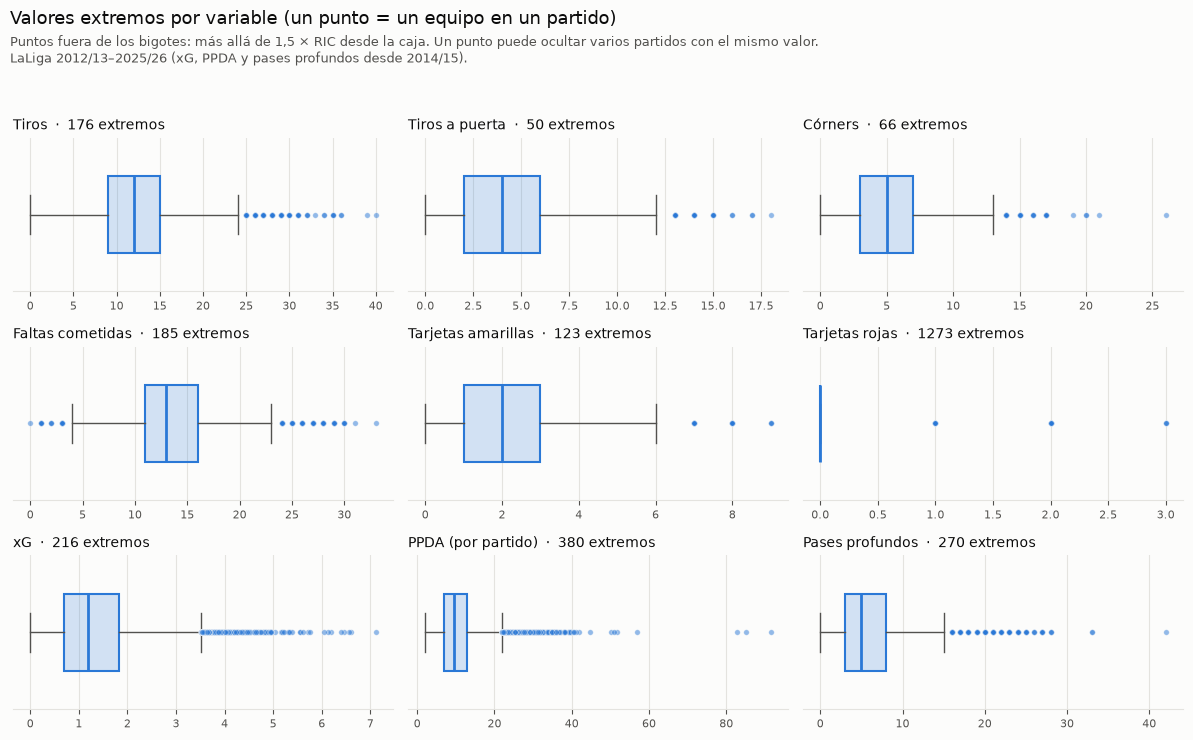

In [28]:
SERIE = "#2a78d6"      # un único color: cada panel es una sola variable
TINTA, TINTA_2, FONDO, REJILLA = "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"

fig, axes = plt.subplots(3, 3, figsize=(12, 7.5), facecolor=FONDO)
for ax, (col, nombre) in zip(axes.flat, VARIABLES.items()):
    s = pe[col].dropna()
    n_ext = resumen_extremos.loc[resumen_extremos.variable == nombre, "extremos"].item()
    ax.boxplot(
        s, orientation="horizontal", widths=0.5, whis=1.5, patch_artist=True,
        boxprops=dict(facecolor=SERIE + "33", edgecolor=SERIE, linewidth=1.5),
        medianprops=dict(color=SERIE, linewidth=2),
        whiskerprops=dict(color=TINTA_2, linewidth=1), capprops=dict(color=TINTA_2, linewidth=1),
        flierprops=dict(marker="o", markersize=4, markerfacecolor=SERIE, markeredgecolor=FONDO,
                        markeredgewidth=0.5, alpha=0.5),
    )
    ax.set_title(f"{nombre}  ·  {n_ext} extremos", loc="left", fontsize=10, color=TINTA)
    ax.set_facecolor(FONDO)
    ax.set_yticks([])
    ax.grid(axis="x", color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(REJILLA)

fig.suptitle("Valores extremos por variable (un punto = un equipo en un partido)",
             x=0.01, ha="left", fontsize=13, color=TINTA)
fig.text(0.01, 0.91, "Puntos fuera de los bigotes: más allá de 1,5 × RIC desde la caja. "
         "Un punto puede ocultar varios partidos con el mismo valor.\n"
         "LaLiga 2012/13–2025/26 (xG, PPDA y pases profundos desde 2014/15).",
         fontsize=9, color=TINTA_2)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(ROOT / "reports" / "figures" / "01_valores_extremos.png", dpi=150, facecolor=FONDO)
plt.show()

### Los casos más extremos

Para cada valor fuera de los bigotes medimos **a cuántos RIC está del borde de la caja**, y listamos los más alejados. Las tarjetas rojas quedan fuera de esta lista (su RIC es 0, ver abajo).

In [29]:
casos = []
for col, nombre in VARIABLES.items():
    if col == "rojas":
        continue
    s = pe[col]
    q1, q3, inf, sup = limites_ric(s.dropna())
    ric = q3 - q1
    distancia = ((s - q3) / ric).where(s > sup, ((q1 - s) / ric).where(s < inf))
    extremos = pe.loc[distancia.notna(), ["temporada", "fecha", "equipo", "rival", "condicion"]].copy()
    extremos["variable"] = nombre
    extremos["valor"] = s[distancia.notna()].round(2)
    extremos["distancia_en_RIC"] = distancia.dropna().round(1)
    casos.append(extremos)

pd.concat(casos).sort_values("distancia_en_RIC", ascending=False).head(12).reset_index(drop=True)

,temporada,fecha,equipo,rival,condicion,variable,valor,distancia_en_RIC
0,2023-24,2023-12-02,Valencia,Girona,visitante,PPDA (por partido),91.5,13.2
1,2025-26,2026-02-08,Real Betis,Atlético de Madrid,visitante,PPDA (por partido),85.0,12.1
2,2022-23,2023-01-22,Getafe,Barcelona,visitante,PPDA (por partido),82.8,11.7
3,2022-23,2022-10-30,Girona,Real Madrid,visitante,PPDA (por partido),56.8,7.3
4,2019-20,2019-12-07,Barcelona,Mallorca,local,Pases profundos,42.0,6.8
5,2016-17,2016-09-10,Alavés,Barcelona,visitante,PPDA (por partido),51.6,6.5
6,2025-26,2026-02-15,Real Betis,Mallorca,visitante,PPDA (por partido),50.86,6.4
7,2020-21,2021-04-18,Cádiz,Celta de Vigo,local,PPDA (por partido),50.29,6.3
8,2024-25,2025-03-31,Las Palmas,Celta de Vigo,visitante,PPDA (por partido),44.62,5.3
9,2024-25,2025-03-02,Barcelona,Real Sociedad,local,Pases profundos,33.0,5.0


Casi todos los casos más extremos son de **PPDA**. Miramos sus dos piezas:

In [30]:
con.sql("""
SELECT temporada, fecha, equipo, rival, ppda_pases, ppda_acciones,
       round(ppda_pases / ppda_acciones, 1) AS ppda
FROM partidos_equipo
WHERE ppda_acciones IS NOT NULL
ORDER BY ppda_pases / ppda_acciones DESC
LIMIT 5
""").df()

,temporada,fecha,equipo,rival,ppda_pases,ppda_acciones,ppda
0,2023-24,2023-12-02,Valencia,Girona,366,4,91.5
1,2025-26,2026-02-08,Real Betis,Atlético de Madrid,340,4,85.0
2,2022-23,2023-01-22,Getafe,Barcelona,414,5,82.8
3,2022-23,2022-10-30,Girona,Real Madrid,284,5,56.8
4,2016-17,2016-09-10,Alavés,Barcelona,258,5,51.6


El PPDA se dispara cuando el **denominador es muy pequeño**: con solo 4–5 acciones defensivas en campo rival (frente a 300–400 pases del rival), una acción más o menos cambia el ratio a la mitad o al doble. No son errores: son equipos que ese día renunciaron a presionar (a menudo contra rivales que dominan la posesión). Es otra razón para haber guardado las piezas y no el ratio: al agregar por temporada (suma de pases ÷ suma de acciones), estos partidos pesan lo que corresponde.

In [31]:
# Las faltas muy bajas son lo más sospechoso: ¿cuántos equipos cometieron 0, 1 o 2?
con.sql("""
SELECT temporada, fecha, equipo, rival, faltas_cometidas, faltas_recibidas
FROM partidos_equipo
WHERE faltas_cometidas <= 2
ORDER BY faltas_cometidas, fecha
""").df()

,temporada,fecha,equipo,rival,faltas_cometidas,faltas_recibidas
0,2017-18,2018-04-22,Real Sociedad,Málaga,0,16
1,2012-13,2013-05-11,Deportivo de La Coruña,Real Valladolid,1,14
2,2016-17,2017-03-18,Athletic Club,Real Madrid,1,4
3,2018-19,2018-09-25,Atlético de Madrid,Huesca,1,14
4,2021-22,2022-04-24,Rayo Vallecano,Barcelona,1,10
5,2024-25,2025-02-23,Real Madrid,Girona,1,7
6,2015-16,2016-03-02,Villarreal,Celta de Vigo,2,9
7,2020-21,2021-05-16,Atlético de Madrid,Osasuna,2,13
8,2025-26,2026-03-22,Real Madrid,Atlético de Madrid,2,15


### Cómo los gestionamos

**Decisión: se conservan todos los valores, sin modificar.** Motivos:

1. **Extremo no es error.** Los valores altos de tiros, córners y xG aparecen **juntos** en los mismos partidos (Real Madrid–Mallorca 2024/25: 39 tiros y 26 córners; Barcelona–Mallorca 2024/25: 40 tiros): son asedios reales, coherentes entre variables.
2. **Las faltas muy bajas (0–2) son lo más sospechoso**: 9 casos, cuando lo habitual son 11–16 por equipo. Podrían ser errores de transcripción (p. ej. 11 → 1), pero **no tenemos prueba**, y el resto de estadísticas de esos partidos es normal.
3. **Borrar o recortar extremos también sesga:** eliminaría justo los partidos excepcionales, y cualquier umbral para hacerlo sería arbitrario.
4. **Impacto bajo en agregados:** un valor en un partido pesa poco en una media de temporada (38 partidos).

**Limitaciones del método, a tener en cuenta al leer el gráfico:**

- **Tarjetas rojas:** más de la mitad de los partidos tienen 0, así que Q1 = Q3 = 0, el RIC vale 0 y **cualquier roja cuenta como extremo** (1.273 casos). No son anomalías: el método no sirve para variables tan concentradas en un solo valor.
- **PPDA, xG y pases profundos** tienen una cola larga hacia arriba (distribuciones asimétricas). Muchos de sus "extremos" son la cola natural de la distribución, no rarezas. En el PPDA, además, los valores más altos vienen de denominadores muy pequeños.

**⚠️ Para la fase 2:** donde un extremo sí puede pesar es en **medias móviles cortas** (p. ej. "últimos 5 partidos"). Allí decidiremos si usamos medidas robustas (mediana) o ventanas más largas.

## 12. Exportación

Guardamos en `data/processed/`:

| Fichero | Contenido |
|---|---|
| `partidos.csv` | Una fila por partido |
| `partidos_equipo.csv` | Una fila por equipo y partido |
| `equipos.csv` | Una fila por equipo (tabla de dimensión para Power BI) |
| `diccionario_datos.csv` | Qué significa cada columna, de qué fuente sale y **cuándo se conoce** |

Formato acordado: fechas ISO (`2014-08-23`), punto decimal, UTF-8. `COPY … TO` es la instrucción de DuckDB para escribir una consulta en un fichero.

In [32]:
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

con.sql("""
CREATE OR REPLACE TABLE equipos_dim AS
SELECT equipo                      AS nombre,
       min(temporada)              AS primera_temporada,
       max(temporada)              AS ultima_temporada,
       count(DISTINCT temporada)   AS temporadas_en_primera
FROM partidos_equipo
GROUP BY equipo
ORDER BY nombre
""")

EXPORTAR = {"partidos": "partidos", "partidos_equipo": "partidos_equipo", "equipos": "equipos_dim"}
for fichero, tabla in EXPORTAR.items():
    destino = (PROCESSED / f"{fichero}.csv").as_posix()
    con.sql(f"COPY (SELECT * FROM {tabla}) TO '{destino}' (HEADER, DELIMITER ',')")
    print(f"{fichero}.csv: {con.sql(f'SELECT count(*) FROM {tabla}').fetchone()[0]} filas")

partidos.csv: 5320 filas
partidos_equipo.csv: 10640 filas
equipos.csv: 33 filas


### Prueba de ida y vuelta

Un CSV no guarda tipos: al releerlo, cada programa los **adivina**. Comprobamos que al releer los ficheros salen las mismas filas y que las columnas clave se reconocen con su tipo correcto (fecha como fecha, xG como decimal). Es lo que hará Power BI al importarlos.

In [33]:
for fichero, tabla in EXPORTAR.items():
    releido = con.sql(f"SELECT * FROM read_csv('{(PROCESSED / f'{fichero}.csv').as_posix()}')")
    original = con.sql(f"SELECT * FROM {tabla}")
    assert releido.columns == original.columns, f"{fichero}: columnas distintas"
    assert len(releido.df()) == len(original.df()), f"{fichero}: filas distintas"

tipos = con.sql(f"""
DESCRIBE SELECT fecha, temporada, resultado, goles_local, xg_local, ppda_pases_local
FROM read_csv('{(PROCESSED / "partidos.csv").as_posix()}')
""").df()[["column_name", "column_type"]]
assert tipos.set_index("column_name").column_type.to_dict() == {
    "fecha": "DATE", "temporada": "VARCHAR", "resultado": "VARCHAR",
    "goles_local": "BIGINT", "xg_local": "DOUBLE", "ppda_pases_local": "BIGINT"}
tipos

,column_name,column_type
0,fecha,DATE
1,temporada,VARCHAR
2,resultado,VARCHAR
3,goles_local,BIGINT
4,xg_local,DOUBLE
5,ppda_pases_local,BIGINT


### Diccionario de datos

Documenta cada columna. La columna `momento` es la más importante para las fases siguientes: indica si el dato **se conoce antes del partido** o **solo después**. Todo lo que sea "después" solo puede usarse como información de partidos **anteriores** al que se analiza o predice.

Se genera desde un listado de conceptos (tiros, xG…) y el `assert` final garantiza que **ninguna columna exportada se queda sin documentar**.

In [34]:
FD, US = "football-data.co.uk", "Understat"
CONCEPTOS = {
    # concepto: (descripción, fuente, disponible desde, momento)
    "id_partido": ("Identificador del partido (orden cronológico)", "Calculado", "2012-13", "antes"),
    "temporada": ("Temporada, p. ej. 2014-15", FD, "2012-13", "antes"),
    "fecha": ("Fecha oficial del partido (la de football-data)", FD, "2012-13", "antes"),
    "local": ("Equipo local", FD, "2012-13", "antes"),
    "visitante": ("Equipo visitante", FD, "2012-13", "antes"),
    "equipo": ("Equipo de la fila", FD, "2012-13", "antes"),
    "rival": ("Rival del equipo de la fila", FD, "2012-13", "antes"),
    "condicion": ("'local' o 'visitante' para el equipo de la fila", FD, "2012-13", "antes"),
    "goles": ("Goles", FD, "2012-13", "después"),
    "resultado": ("En partidos: 1 (gana local), X (empate), 2 (gana visitante). En partidos_equipo: victoria, empate o derrota", FD, "2012-13", "después"),
    "puntos": ("Puntos obtenidos: 3, 1 o 0", "Calculado", "2012-13", "después"),
    "tiros": ("Tiros totales", FD, "2012-13", "después"),
    "tiros_puerta": ("Tiros a puerta", FD, "2012-13", "después"),
    "corners": ("Córners", FD, "2012-13", "después"),
    "faltas": ("Faltas cometidas", FD, "2012-13", "después"),
    "faltas_cometidas": ("Faltas cometidas por el equipo", FD, "2012-13", "después"),
    "faltas_recibidas": ("Faltas cometidas por el rival", FD, "2012-13", "después"),
    "amarillas": ("Tarjetas amarillas", FD, "2012-13", "después"),
    "rojas": ("Tarjetas rojas", FD, "2012-13", "después"),
    "xg": ("Goles esperados (calidad de las ocasiones)", US, "2014-15", "después"),
    "npxg": ("Goles esperados sin penaltis", US, "2014-15", "después"),
    "ppda_pases": ("Pases completados por el rival en su campo (numerador del PPDA). PPDA = suma de pases / suma de acciones; nunca promediar ratios", US, "2014-15", "después"),
    "ppda_acciones": ("Acciones defensivas del equipo en campo rival (denominador del PPDA)", US, "2014-15", "después"),
    "ppda_pases_rival": ("Numerador del PPDA del rival (presión recibida)", US, "2014-15", "después"),
    "ppda_acciones_rival": ("Denominador del PPDA del rival (presión recibida)", US, "2014-15", "después"),
    "pases_profundos": ("Pases completados a menos de ~20 m de la portería rival, sin centros", US, "2014-15", "después"),
    "puntos_esperados": ("Puntos esperados según el xG del partido", US, "2014-15", "después"),
    "id_understat": ("Identificador del partido en Understat (trazabilidad)", US, "2014-15", "antes"),
    "nombre": ("Nombre del equipo", "Calculado", "2012-13", "antes"),
    "primera_temporada": ("Primera temporada del equipo en Primera dentro del periodo", "Calculado", "2012-13", "antes"),
    "ultima_temporada": ("Última temporada del equipo en Primera dentro del periodo", "Calculado", "2012-13", "antes"),
    "temporadas_en_primera": ("Temporadas en Primera dentro del periodo (2012-13 a 2025-26)", "Calculado", "2012-13", "antes"),
}
SUFIJOS = {"_local": "del equipo local", "_visitante": "del equipo visitante",
           "_favor": "del equipo de la fila", "_contra": "del rival"}

def describir(columna):
    if columna in CONCEPTOS:
        return CONCEPTOS[columna]
    for sufijo, texto in SUFIJOS.items():
        base = columna.removesuffix(sufijo)
        if base != columna and base in CONCEPTOS:
            desc, fuente, desde, momento = CONCEPTOS[base]
            return (f"{desc} {texto}", fuente, desde, momento)
    raise KeyError(f"Columna sin documentar: {columna}")

filas = []
for fichero, tabla in EXPORTAR.items():
    for columna, tipo in con.sql(f"DESCRIBE {tabla}").df()[["column_name", "column_type"]].values:
        desc, fuente, desde, momento = describir(columna)
        filas.append({"fichero": f"{fichero}.csv", "columna": columna, "tipo": tipo,
                      "descripcion": desc, "fuente": fuente, "disponible_desde": desde,
                      "momento": f"se conoce {momento} del partido"})

diccionario = pd.DataFrame(filas)
diccionario.to_csv(PROCESSED / "diccionario_datos.csv", index=False, encoding="utf-8")
print(f"{len(diccionario)} columnas documentadas")
diccionario[diccionario.fichero == "partidos_equipo.csv"].head(12)

68 columnas documentadas


,fichero,columna,tipo,descripcion,fuente,disponible_desde,momento
33,partidos_equipo.csv,id_partido,INTEGER,Identificador del partido (orden cronológico),Calculado,2012-13,se conoce antes del partido
34,partidos_equipo.csv,temporada,VARCHAR,"Temporada, p. ej. 2014-15",football-data.co.uk,2012-13,se conoce antes del partido
35,partidos_equipo.csv,fecha,DATE,Fecha oficial del partido (la de football-data),football-data.co.uk,2012-13,se conoce antes del partido
36,partidos_equipo.csv,equipo,VARCHAR,Equipo de la fila,football-data.co.uk,2012-13,se conoce antes del partido
37,partidos_equipo.csv,rival,VARCHAR,Rival del equipo de la fila,football-data.co.uk,2012-13,se conoce antes del partido
38,partidos_equipo.csv,condicion,VARCHAR,'local' o 'visitante' para el equipo de la fila,football-data.co.uk,2012-13,se conoce antes del partido
39,partidos_equipo.csv,goles_favor,INTEGER,Goles del equipo de la fila,football-data.co.uk,2012-13,se conoce después del partido
40,partidos_equipo.csv,goles_contra,INTEGER,Goles del rival,football-data.co.uk,2012-13,se conoce después del partido
41,partidos_equipo.csv,resultado,VARCHAR,"En partidos: 1 (gana local), X (empate), 2 (ga...",football-data.co.uk,2012-13,se conoce después del partido
42,partidos_equipo.csv,puntos,INTEGER,"Puntos obtenidos: 3, 1 o 0",Calculado,2012-13,se conoce después del partido


## Resumen de la fase 1

- **5.320 partidos** (14 temporadas, 2 de ellas solo para calentar el Elo), **4.560 con datos de Understat**.
- Las dos fuentes **coinciden en los goles de todos los partidos**. Las únicas discrepancias son de fecha: 65 por zona horaria y 5 casos concretos documentados.
- **Ningún imposible lógico** en las estadísticas. Los valores extremos se conservan y están documentados.
- Trampas evitadas por el camino: fechas del año 14 d.C., pérdida no aleatoria de partidos nocturnos si hubiéramos cruzado por fecha, regla falsa de "goles ≤ tiros a puerta", promedios de ratios de PPDA.